# ABLATION: No Casing Embedding

**Komponen dihapus:** Case embedding (16-d, allLower/allUpper/initialUpper/dll)
**Penyebab:** Menguji kontribusi fitur casing (case information biasanya sudah ada di tokenizer)
**Prediksi:** Δ F1 = 0 to -0.3 (marginal — ModernBERT tokenizer sudah case-sensitive)

**Perubahan dari baseline:**
- `CFG.USE_CASING = False` → skip case_embed
- `lstm_in` dikurangi `cfg.CASE_DIM` (16-d)
- BiLSTM input: 1024 + 100 + 32 + 0 = 1156 (dari 1172)


In [1]:
import os, re, gc, csv, json, math, random, warnings, time, traceback
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Any
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from torchcrf import CRF
import evaluate

import nltk
for pkg in ['averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng', 'punkt', 'punkt_tab']:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass
from nltk import pos_tag, word_tokenize

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [2]:
@dataclass
class CFG:
    DAPT_MODEL_PATH: str = r"./disaster_modernbert_large_stableadamw_wsd_compile_mlm15"
    DATA_PATH: str = r"./data/dataset.txt"
    OUTPUT_DIR: str = r"./Output/ModernBERT_Ega_ABLASI_CRF_POS"

    SPLIT_SEED: int = 42
    TRAIN_SEED: int = 42

    MAX_LENGTH: int = 8192
    BATCH_SIZE: int = 8
    ACCUM_STEPS: int = 2
    EPOCHS: int = 20
    USE_EARLY_STOPPING: bool = True
    PATIENCE: int = 4
    GRAD_CLIP: float = 1.0

    # === Learning Rates (absolute, not ratios) ===
    LR_ENCODER: float = 0.00001   # Encoder pre-trained
    LR_HEAD: float = 0.00005      # 5× encoder — head random init butuh belajar lebih cepat
    CRF_LR_MULT: float = 2.0      # CRF = 2× head = 1e-4
    LAYER_LR_DECAY: float = 0.92
    MIN_LR_FACTOR: float = 0.01 # kenapa 0 (pelajari learning rate scheduler)

    WEIGHT_DECAY: float = 0.01
    WARMUP_EPOCHS: int = 3        # absolut, bukan ratio 0.15
    OPTIMIZER_NAME: str = "StableAdamW"
    STABLE_ADAMW_BETAS: tuple = (0.9, 0.99) #lakuin research ga
    STABLE_ADAMW_EPS: float = 0.00000001 #lakuin research juga ya
    SCHEDULER_NAME: str = "WSD"
    WSD_DECAY_EPOCHS: int = 4     # absolut, bukan ratio 0.20

    # === Dropout ===
    DROPOUT: float = 0.45         # BiLSTM dropout
    ENCODER_DROPOUT: float = 0.15  # Regularisasi ringan encoder output (ModernBERT: 0 dropout saat pretrain)
    HIDDEN_DIM: int = 150
    LSTM_LAYERS: int = 2
    USE_SELF_ATTENTION: bool = False

    # === CharCNN ===
    CHAR_EMBED_DIM: int = 52
    CHAR_OUT_DIM: int = 100
    POS_DIM: int = 32
    CASE_DIM: int = 16
    CHAR_KERNEL_SIZES: tuple = (4, 3, 3)
    CHAR_FILTER_SIZES: tuple = (33, 33, 34)

    LOSS_TYPE: str = "CRF"
    SUBWORD_STRATEGY: str = "all_subwords"

    USE_MENTION_REPLACEMENT: bool = True
    MENTION_REPLACEMENT_PROB: float = 0.50
    OVERSAMPLE_SEED: int = 42

    USE_FLASH_ATTN: bool = True
    USE_AMP: bool = True
    AMP_DTYPE: str = "bf16"
    GRADIENT_CHECKPOINTING: bool = True

    # === ABLATION FLAGS (set False untuk disable komponen) ===
    ABLATION_NAME: str = "5_CRF-POS"
    USE_ENCODER: bool = True   # ModernBERT-Large encoder (DAPT)
    USE_CHARCNN: bool = False   # CharCNN character features
    USE_POS: bool = True       # POS tag embedding
    USE_CASING: bool = False    # Case embedding
    USE_BILSTM: bool = False    # BiLSTM sequence modeling
    USE_CRF: bool = True       # CRF sequence decoding
    
    # === ENCODER REPLACEMENT (untuk ABL_NoModernBERT) ===
    ENCODER_REPLACEMENT: str = "random_transformer"  # 'random_transformer' atau 'bilstm'
    RANDOM_ENC_LAYERS: int = 6
    RANDOM_ENC_HIDDEN: int = 512
    RANDOM_ENC_HEADS: int = 8

    LOG_EVAL_LOSS: bool = True

cfg = CFG()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

print(f"Config loaded for: {cfg.OUTPUT_DIR}")
print(f"Split: 64/16/20 (train/dev/test)")
print(f"Epochs: {cfg.EPOCHS} | Warmup: {cfg.WARMUP_EPOCHS} epoch | Decay: {cfg.WSD_DECAY_EPOCHS} epoch | Plateau: {cfg.EPOCHS - cfg.WARMUP_EPOCHS - cfg.WSD_DECAY_EPOCHS} epoch")
print(f"LR enc={cfg.LR_ENCODER} | LR head={cfg.LR_HEAD} | CRF={cfg.LR_HEAD * cfg.CRF_LR_MULT}")
print(f"Encoder dropout: {cfg.ENCODER_DROPOUT} | BiLSTM dropout: {cfg.DROPOUT}")
print(f"Patience: {cfg.PATIENCE} | Early stop on: dev loss")

Config loaded for: ./Output/ModernBERT_Ega_ABLASI_CRF_POS
Split: 64/16/20 (train/dev/test)
Epochs: 20 | Warmup: 3 epoch | Decay: 4 epoch | Plateau: 13 epoch
LR enc=1e-05 | LR head=5e-05 | CRF=0.0001
Encoder dropout: 0.15 | BiLSTM dropout: 0.45
Patience: 4 | Early stop on: dev loss


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # BUG FIX: tambahkan deterministic algorithms untuk full reproducibility
    # warn_only=True agar tidak crash jika ada op non-deterministic (misal flash attention path)
    torch.use_deterministic_algorithms(True, warn_only=True)

def clean_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def get_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_amp_dtype():
    if cfg.AMP_DTYPE.lower() == 'bf16':
        return torch.bfloat16
    if cfg.AMP_DTYPE.lower() == 'fp16':
        return torch.float16
    return torch.float32

def to_jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if torch.is_tensor(obj):
        return obj.detach().cpu().tolist()
    return obj

def save_json(obj, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(to_jsonable(obj), f, indent=2, ensure_ascii=False)

LABEL_LIST = [
    'O',
    'B-NaturalHazards',      'I-NaturalHazards',
    'B-Location',            'I-Location',
    'B-Date',                'I-Date',
    'B-Floods',              'I-Floods',
    'B-Fire',                'I-Fire',
    'B-Death_And_Toll',      'I-Death_And_Toll',
    'B-InfrastructureDamage','I-InfrastructureDamage',
    'B-CollapsedStructure',  'I-CollapsedStructure',
    'B-RoadBlocked',         'I-RoadBlocked',
    'B-MissingPersons',      'I-MissingPersons',
    'B-PowerOutage',         'I-PowerOutage',
    'B-AffectedPopulation',  'I-AffectedPopulation',
    'B-WaterShortage',       'I-WaterShortage',
]
label2id = {l: i for i, l in enumerate(LABEL_LIST)}
id2label = {i: l for i, l in enumerate(LABEL_LIST)}
num_labels = len(LABEL_LIST)
ENTITY_TYPES = sorted({x[2:] for x in LABEL_LIST if x != 'O'})

CHAR_ALPHABET = '0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ./,-()[]{}!?:;#\' "%$ &=*+@^~`|'
char2id = {c: i + 1 for i, c in enumerate(CHAR_ALPHABET)}
CHAR_VOCAB_SIZE = len(char2id) + 1
MAX_WORD_LEN = 20

case2id = {
    'numeric': 0, 'allLower': 1, 'allUpper': 2, 'initialUpper': 3,
    'other': 4, 'mainly_numeric': 5, 'contains_digit': 6, 'PADDING_TOKEN': 7,
}
id2case = {v: k for k, v in case2id.items()}

def get_casing(word: str) -> str:
    if not word:
        return 'other'
    if word.isdigit():
        return 'numeric'
    num_digits = sum(c.isdigit() for c in word)
    if num_digits / max(1, len(word)) > 0.5:
        return 'mainly_numeric'
    if word.islower():
        return 'allLower'
    if word.isupper():
        return 'allUpper'
    if word[0].isupper():
        return 'initialUpper'
    if num_digits > 0:
        return 'contains_digit'
    return 'other'

print('Device:', get_device())
print('Num labels:', num_labels)

Using device: cuda
Device: cuda
Num labels: 27


In [4]:
def normalize_tag(tag: str) -> str:
    tag = tag.strip()
    tag = tag.replace('WaterShrotage', 'WaterShortage')
    if tag in {'', 'O'}:
        return 'O'
    return tag

def fix_bio_sequence(tags):
    fixed = []
    prev_type = None
    prev_prefix = 'O'
    for tag in tags:
        tag = normalize_tag(tag)
        if tag == 'O':
            fixed.append('O')
            prev_type = None
            prev_prefix = 'O'
            continue
        if '-' not in tag:
            fixed.append('O')
            prev_type = None
            prev_prefix = 'O'
            continue
        prefix, ent = tag.split('-', 1)
        if prefix == 'I' and (prev_prefix == 'O' or prev_type != ent):
            tag = 'B-' + ent
            prefix = 'B'
        fixed.append(tag)
        prev_prefix = prefix
        prev_type = ent
    return fixed

def load_conll_dataset(path):
    sentences, labels = [], []
    cur_tokens, cur_labels = [], []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                if cur_tokens:
                    labels.append(fix_bio_sequence(cur_labels))
                    sentences.append(cur_tokens)
                    cur_tokens, cur_labels = [], []
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            token, tag = parts[0], normalize_tag(parts[-1])
            if tag not in label2id:
                tag = 'O'
            cur_tokens.append(token)
            cur_labels.append(tag)
    if cur_tokens:
        labels.append(fix_bio_sequence(cur_labels))
        sentences.append(cur_tokens)
    return sentences, labels

def count_entities(label_sequences):
    counts = Counter()
    for seq in label_sequences:
        for tag in seq:
            if tag.startswith('B-'):
                counts[tag[2:]] += 1
    return counts

RARE_SYNONYMS = {
    'MissingPersons': ['missing person', 'lost person', 'unaccounted person', 'swept away', 'trapped victim'],
    'PowerOutage': ['power outage', 'blackout', 'electricity blackout', 'grid failure', 'power cut', 'power failure'],
    'RoadBlocked': ['road blocked', 'road closed', 'blocked access', 'impassable road', 'road cut off'],
    'WaterShortage': ['water shortage', 'clean water crisis', 'lack of water', 'water drought', 'no water supply'],
    'InfrastructureDamage': ['bridge collapse', 'damaged facilities', 'dyke breach', 'building damage', 'infrastructure destruction'],
    'CollapsedStructure': ['collapsed house', 'collapsed building', 'debris pile', 'cracked wall', 'ruined structure'],
    'AffectedPopulation': ['affected residents', 'displaced people', 'survivors', 'evacuated population', 'affected families']
}

def augment_rare_mentions(sentences, labels, prob, seed):
    rng = random.Random(seed)
    aug_sentences = []
    aug_labels = []
    for words, tags in zip(sentences, labels):
        has_rare = any(t[2:] in RARE_SYNONYMS for t in tags if t.startswith('B-'))
        if has_rare and rng.random() < prob:
            new_words = list(words)
            new_tags = list(tags)
            i = 0
            while i < len(tags):
                tag = tags[i]
                if tag.startswith('B-'):
                    ent_type = tag[2:]
                    if ent_type in RARE_SYNONYMS:
                        start = i
                        end = i + 1
                        while end < len(tags) and tags[end].startswith('I-') and tags[end][2:] == ent_type:
                            end += 1
                        synonym = rng.choice(RARE_SYNONYMS[ent_type])
                        syn_words = synonym.split()
                        syn_tags = ['B-' + ent_type] + ['I-' + ent_type] * (len(syn_words) - 1)
                        new_words[start:end] = syn_words
                        new_tags[start:end] = syn_tags
                        i = start + len(syn_words)
                        continue
                i += 1
            aug_sentences.append(new_words)
            aug_labels.append(new_tags)
    return aug_sentences, aug_labels

# ── PROPER 64/16/20 SPLIT ──
set_seed(cfg.SPLIT_SEED)
sentences_raw, labels_raw = load_conll_dataset(cfg.DATA_PATH)
print(f'Total kalimat: {len(sentences_raw):,}')

idx = list(range(len(sentences_raw)))
train_idx, test_idx = train_test_split(idx, test_size=0.20, random_state=cfg.SPLIT_SEED, shuffle=True)
train_idx, dev_idx = train_test_split(train_idx, test_size=0.20, random_state=cfg.SPLIT_SEED, shuffle=True)
# train = 64% (80% * 80%), dev = 16% (20% * 80%), test = 20%

sent_train_raw = [sentences_raw[i] for i in train_idx]
lab_train_raw = [labels_raw[i] for i in train_idx]
sent_dev = [sentences_raw[i] for i in dev_idx]
lab_dev = [labels_raw[i] for i in dev_idx]
sent_test = [sentences_raw[i] for i in test_idx]
lab_test = [labels_raw[i] for i in test_idx]

if cfg.USE_MENTION_REPLACEMENT:
    aug_sent, aug_lab = augment_rare_mentions(
        sent_train_raw, lab_train_raw,
        prob=cfg.MENTION_REPLACEMENT_PROB,
        seed=cfg.OVERSAMPLE_SEED
    )
    print(f"Augmented training set: added {len(aug_sent):,} rare entity sentences.")
    sent_train_raw = sent_train_raw + aug_sent
    lab_train_raw = lab_train_raw + aug_lab

sent_train, lab_train = sent_train_raw, lab_train_raw

print('\n' + '='*60)
print('DATA SPLIT (64/16/20)')
print('='*60)
print(f'Train: {len(sent_train):,} kalimat (64%)')
print(f'Dev:   {len(sent_dev):,} kalimat (16%)')
print(f'Test:  {len(sent_test):,} kalimat (20%) — disentuh SEKALI di akhir')
print('='*60)
print('Entity count train:', count_entities(lab_train))
print('Entity count dev:',   count_entities(lab_dev))
print('Entity count test:',  count_entities(lab_test))

Total kalimat: 19,206
Augmented training set: added 142 rare entity sentences.

DATA SPLIT (64/16/20)
Train: 12,433 kalimat (64%)
Dev:   3,073 kalimat (16%)
Test:  3,842 kalimat (20%) — disentuh SEKALI di akhir
Entity count train: Counter({'Location': 6307, 'Date': 3214, 'NaturalHazards': 2985, 'Floods': 1237, 'Death_And_Toll': 381, 'AffectedPopulation': 194, 'Fire': 153, 'CollapsedStructure': 91, 'InfrastructureDamage': 74, 'PowerOutage': 58, 'WaterShortage': 55, 'RoadBlocked': 30, 'MissingPersons': 7})
Entity count dev: Counter({'Location': 1428, 'Date': 811, 'NaturalHazards': 741, 'Floods': 275, 'Death_And_Toll': 132, 'Fire': 47, 'AffectedPopulation': 30, 'CollapsedStructure': 20, 'InfrastructureDamage': 12, 'PowerOutage': 8, 'WaterShortage': 7, 'RoadBlocked': 3, 'MissingPersons': 2})
Entity count test: Counter({'Location': 1938, 'Date': 989, 'NaturalHazards': 844, 'Floods': 408, 'Death_And_Toll': 163, 'Fire': 42, 'AffectedPopulation': 23, 'PowerOutage': 15, 'CollapsedStructure': 15

In [5]:
print('Membangun POS dictionary dari training set...')
all_pos_tags = set()
for sent in tqdm(sent_train, desc='POS tagging train'):
    try:
        all_pos_tags.update([p for _, p in pos_tag(sent)])
    except Exception:
        all_pos_tags.update(['NN'])

pos2id = {p: i + 1 for i, p in enumerate(sorted(all_pos_tags))}
pos2id['PADDING_TOKEN'] = 0
id2pos = {v: k for k, v in pos2id.items()}
print('Jumlah POS tag:', len(pos2id))

def words_to_char_ids(words):
    arr = []
    for word in words:
        ids = [char2id.get(ch, 0) for ch in str(word)[:MAX_WORD_LEN]]
        ids += [0] * (MAX_WORD_LEN - len(ids))
        arr.append(ids)
    return torch.tensor(arr, dtype=torch.long)

def extract_pos_case_ids(words):
    try:
        tagged = pos_tag(words)
    except Exception:
        tagged = [(w, 'NN') for w in words]
    pos_ids, case_ids = [], []
    for word, ptag in tagged:
        pos_ids.append(pos2id.get(ptag, 0))
        case_ids.append(case2id.get(get_casing(word), case2id['other']))
    return pos_ids, case_ids

def subword_label(tag, is_first):
    if is_first:
        return label2id.get(tag, 0)
    if cfg.SUBWORD_STRATEGY == 'all_subwords':
        if tag.startswith('B-'):
            tag = 'I-' + tag[2:]
        return label2id.get(tag, 0)
    return -100

tokenizer = AutoTokenizer.from_pretrained(cfg.DAPT_MODEL_PATH)

class NERDataset(Dataset):
    def __init__(self, sents, labels=None, tokenizer=None, max_len=8192):
        self.samples = []
        has_labels = labels is not None
        labels = labels if labels is not None else [['O'] * len(s) for s in sents]
        for tokens, tags in tqdm(list(zip(sents, labels)), desc='Build dataset'):
            tok = tokenizer(tokens, truncation=True, max_length=max_len, is_split_into_words=True)
            word_ids = tok.word_ids()
            aligned = []
            first_mask = []
            prev_wid = None
            for wid in word_ids:
                if wid is None:
                    aligned.append(-100)
                    first_mask.append(0)
                else:
                    is_first = wid != prev_wid
                    tag = tags[min(wid, len(tags) - 1)]
                    aligned.append(subword_label(tag, is_first))
                    first_mask.append(1 if is_first else 0)
                prev_wid = wid

            token_strs = tokenizer.convert_ids_to_tokens(tok['input_ids'])
            char_ids = words_to_char_ids(token_strs)

            # ABLATION: skip POS/case extraction sesuai flag
            if cfg.USE_POS or cfg.USE_CASING:
                pos_word, case_word = extract_pos_case_ids(tokens)
            else:
                pos_word, case_word = [], []
            pos_ids = np.zeros(len(word_ids), dtype=np.int64)
            case_ids = np.zeros(len(word_ids), dtype=np.int64)
            for i, wid in enumerate(word_ids):
                if (cfg.USE_POS or cfg.USE_CASING) and wid is not None and wid < len(pos_word):
                    if cfg.USE_POS:
                        pos_ids[i] = pos_word[wid]
                    if cfg.USE_CASING:
                        case_ids[i] = case_word[wid]

            self.samples.append({
                'input_ids': torch.tensor(tok['input_ids'], dtype=torch.long),
                'attention_mask': torch.tensor(tok['attention_mask'], dtype=torch.long),
                'labels': torch.tensor(aligned, dtype=torch.long),
                'first_mask': torch.tensor(first_mask, dtype=torch.long),
                'char_ids': char_ids,
                'pos_ids': torch.tensor(pos_ids, dtype=torch.long),
                'case_ids': torch.tensor(case_ids, dtype=torch.long),
                'word_ids': word_ids,
                'tokens': tokens,
                'has_labels': has_labels,
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

def collate_fn(batch):
    ml = max(len(x['input_ids']) for x in batch)
    out = {}
    out['input_ids'] = torch.stack([F.pad(x['input_ids'], (0, ml - len(x['input_ids'])), value=0) for x in batch])
    out['attention_mask'] = torch.stack([F.pad(x['attention_mask'], (0, ml - len(x['attention_mask'])), value=0) for x in batch])
    out['labels'] = torch.stack([F.pad(x['labels'], (0, ml - len(x['labels'])), value=-100) for x in batch])
    out['first_mask'] = torch.stack([F.pad(x['first_mask'], (0, ml - len(x['first_mask'])), value=0) for x in batch])
    out['pos_ids'] = torch.stack([F.pad(x['pos_ids'], (0, ml - len(x['pos_ids'])), value=0) for x in batch])
    out['case_ids'] = torch.stack([F.pad(x['case_ids'], (0, ml - len(x['case_ids'])), value=case2id['PADDING_TOKEN']) for x in batch])

    char_ids = []
    for x in batch:
        c = x['char_ids']
        if c.shape[0] < ml:
            c = F.pad(c, (0, 0, 0, ml - c.shape[0]), value=0)
        char_ids.append(c)
    out['char_ids'] = torch.stack(char_ids)
    out['tokens'] = [x['tokens'] for x in batch]
    out['word_ids'] = [x['word_ids'] for x in batch]
    return out

train_ds = NERDataset(sent_train, lab_train, tokenizer, cfg.MAX_LENGTH)
dev_ds = NERDataset(sent_dev, lab_dev, tokenizer, cfg.MAX_LENGTH)
test_ds = NERDataset(sent_test, lab_test, tokenizer, cfg.MAX_LENGTH)  # Disimpan, tidak disentuh sampai final

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, collate_fn=collate_fn, pin_memory=True)
dev_loader = DataLoader(dev_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, collate_fn=collate_fn, pin_memory=True)

print(f'Train: {len(train_ds):,} → {len(train_loader):,} batch')
print(f'Dev:   {len(dev_ds):,} → {len(dev_loader):,} batch')
print(f'Test:  {len(test_ds):,} → {len(test_loader):,} batch (🔒 locked until final eval)')

Membangun POS dictionary dari training set...


POS tagging train:   0%|          | 0/12433 [00:00<?, ?it/s]

Jumlah POS tag: 45


Build dataset:   0%|          | 0/12433 [00:00<?, ?it/s]

Build dataset:   0%|          | 0/3073 [00:00<?, ?it/s]

Build dataset:   0%|          | 0/3842 [00:00<?, ?it/s]

Train: 12,433 → 1,555 batch
Dev:   3,073 → 385 batch
Test:  3,842 → 481 batch (🔒 locked until final eval)


In [6]:
class CharCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, out_dim, kernel_sizes, filter_sizes, dropout):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, f, kernel_size=k, padding='same')
            for k, f in zip(kernel_sizes, filter_sizes)
        ])
        self.proj = nn.Linear(sum(filter_sizes), out_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, char_ids):
        b, s, w = char_ids.shape
        x = self.embed(char_ids.view(b * s, w)).permute(0, 2, 1)
        outs = []
        for conv in self.convs:
            c = conv(x)
            c = F.max_pool1d(c, c.shape[-1]).squeeze(-1)
            outs.append(c)
        x = torch.cat(outs, dim=-1)
        x = self.drop(self.proj(x))
        return x.view(b, s, -1)

def load_automodel_safely(model_path, use_flash, dtype_):
    attempts = []
    if use_flash:
        attempts.append({'attn_implementation': 'flash_attention_2', 'torch_dtype': dtype_})
    attempts.append({'attn_implementation': 'eager', 'torch_dtype': dtype_})
    attempts.append({})
    last_err = None
    for kwargs in attempts:
        try:
            return AutoModel.from_pretrained(model_path, **kwargs)
        except Exception as e:
            last_err = e
    raise last_err

class DisasterModernBertFinal(nn.Module):
    def __init__(self, cfg, num_labels, num_pos, num_cases, char_vocab_size, tokenizer=None):
        super().__init__()
        dtype_ = get_amp_dtype() if cfg.USE_AMP else torch.float32
        
        # Simpan flag ablation ke self
        self.use_charcnn = cfg.USE_CHARCNN
        self.use_pos = cfg.USE_POS
        self.use_casing = cfg.USE_CASING
        self.use_bilstm = cfg.USE_BILSTM
        self.use_crf = cfg.USE_CRF
        self.use_encoder = cfg.USE_ENCODER
        
        # === ENCODER ===
        if cfg.USE_ENCODER:
            self.encoder = load_automodel_safely(cfg.DAPT_MODEL_PATH, cfg.USE_FLASH_ATTN and torch.cuda.is_available(), dtype_)
            if cfg.GRADIENT_CHECKPOINTING and hasattr(self.encoder, 'gradient_checkpointing_enable'):
                self.encoder.gradient_checkpointing_enable()
            enc_h = self.encoder.config.hidden_size
        else:
            # ABLATION: random init encoder replacement
            self.encoder = self._build_replacement_encoder(cfg, dtype_, tokenizer)
            enc_h = self.encoder.config.hidden_size
        
        self.encoder_norm = nn.LayerNorm(enc_h, eps=1e-5)
        self.encoder_dropout = cfg.ENCODER_DROPOUT
        
        # === CONDITIONAL FEATURE EXTRACTORS ===
        if cfg.USE_CHARCNN:
            self.char_cnn = CharCNN(
                vocab_size=char_vocab_size, embed_dim=cfg.CHAR_EMBED_DIM, out_dim=cfg.CHAR_OUT_DIM,
                kernel_sizes=cfg.CHAR_KERNEL_SIZES, filter_sizes=cfg.CHAR_FILTER_SIZES, dropout=cfg.DROPOUT,
            )
        
        if cfg.USE_POS:
            self.pos_embed = nn.Embedding(num_pos, cfg.POS_DIM, padding_idx=0)
        
        if cfg.USE_CASING:
            self.case_embed = nn.Embedding(num_cases, cfg.CASE_DIM, padding_idx=case2id['PADDING_TOKEN'])
        
        # === HITUNG DIMENSI INPUT BiLSTM ===
        in_dim = enc_h
        if cfg.USE_CHARCNN:
            in_dim += cfg.CHAR_OUT_DIM
        if cfg.USE_POS:
            in_dim += cfg.POS_DIM
        if cfg.USE_CASING:
            in_dim += cfg.CASE_DIM
        lstm_in = in_dim
        
        # === BiLSTM ===
        if cfg.USE_BILSTM:
            self.bilstm = nn.LSTM(
                input_size=lstm_in, hidden_size=cfg.HIDDEN_DIM // 2, num_layers=cfg.LSTM_LAYERS,
                batch_first=True, bidirectional=True, dropout=cfg.DROPOUT if cfg.LSTM_LAYERS > 1 else 0.0,
            )
            classifier_in = cfg.HIDDEN_DIM
        else:
            self.bilstm = None
            classifier_in = lstm_in
        
        # === SELF-ATTENTION (opsional, default off) ===
        self.use_self_attention = cfg.USE_SELF_ATTENTION
        if self.use_self_attention:
            self.self_attn = nn.MultiheadAttention(
                embed_dim=classifier_in, num_heads=cfg.NUM_HEADS, dropout=cfg.ATTN_DROPOUT, batch_first=True,
            )
            self.attn_norm = nn.LayerNorm(classifier_in, eps=1e-5)
        
        # === CLASSIFIER ===
        self.drop = nn.Dropout(cfg.DROPOUT)
        self.hidden2tag = nn.Linear(classifier_in, num_labels)
        
        # === CRF ===
        if cfg.USE_CRF:
            self.crf = CRF(num_labels, batch_first=True)
        else:
            self.crf = None

    def _build_replacement_encoder(self, cfg, dtype_, tokenizer=None):
        """Build replacement encoder saat USE_ENCODER=False (ABL_NoModernBERT)."""
        from transformers import AutoConfig, AutoModel
        if cfg.ENCODER_REPLACEMENT == 'random_transformer':
            config = AutoConfig.from_pretrained(cfg.DAPT_MODEL_PATH)
            config.num_hidden_layers = cfg.RANDOM_ENC_LAYERS
            config.hidden_size = cfg.RANDOM_ENC_HIDDEN
            config.num_attention_heads = cfg.RANDOM_ENC_HEADS
            config.intermediate_size = cfg.RANDOM_ENC_HIDDEN * 4
            model = AutoModel.from_config(config)
            return model
        elif cfg.ENCODER_REPLACEMENT == 'bilstm':
            # Use BiLSTM-only stack as encoder
            class BiLSTMEncoder:
                """Wrapper untuk BiLSTM stack yang meniru interface AutoModel."""
                def __init__(self, vocab_size, hidden_size=256, num_layers=2, dropout=0.1):
                    self.embed = nn.Embedding(vocab_size, hidden_size, padding_idx=0)
                    self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers=num_layers, 
                                         batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0.0)
                    self.config = type('Config', (), {'hidden_size': hidden_size * 2})()
                
                def gradient_checkpointing_disable(self):
                    pass
                
                def forward(self, input_ids, attention_mask=None, **kwargs):
                    emb = self.embed(input_ids)
                    out, _ = self.lstm(emb)
                    # Wrap output
                    class Output:
                        pass
                    output = Output()
                    output.last_hidden_state = out
                    return output
            
            vocab_size = tokenizer.vocab_size if tokenizer else 50000
            return BiLSTMEncoder(vocab_size=vocab_size, hidden_size=256, num_layers=2, dropout=0.1)
        else:
            raise ValueError(f'Unknown ENCODER_REPLACEMENT: {cfg.ENCODER_REPLACEMENT}')


    def get_optimizer_grouped_parameters(self):
        layers = []
        if hasattr(self.encoder, 'layers'):
            layers = list(self.encoder.layers)
        elif hasattr(self.encoder, 'encoder') and hasattr(self.encoder.encoder, 'layer'):
            layers = list(self.encoder.encoder.layer)

        groups = []
        if layers:
            n = len(layers)
            g1, g2, g3 = layers[:n//3], layers[n//3:2*n//3], layers[2*n//3:]
            def params(ms):
                return [p for m in ms for p in m.parameters() if p.requires_grad]
            layer_param_ids = set(id(p) for layer in layers for p in layer.parameters())
            other_encoder_params = [p for p in self.encoder.parameters() if p.requires_grad and id(p) not in layer_param_ids]
            groups += [
                {'params': params(g1), 'lr': cfg.LR_ENCODER * cfg.LAYER_LR_DECAY**2, 'weight_decay': cfg.WEIGHT_DECAY},
                {'params': params(g2), 'lr': cfg.LR_ENCODER * cfg.LAYER_LR_DECAY, 'weight_decay': cfg.WEIGHT_DECAY},
                {'params': params(g3), 'lr': cfg.LR_ENCODER, 'weight_decay': cfg.WEIGHT_DECAY},
                {'params': other_encoder_params, 'lr': cfg.LR_ENCODER * cfg.LAYER_LR_DECAY**2, 'weight_decay': cfg.WEIGHT_DECAY},
            ]
        else:
            groups.append({'params': [p for p in self.encoder.parameters() if p.requires_grad], 'lr': cfg.LR_ENCODER, 'weight_decay': cfg.WEIGHT_DECAY})

        # Head modules: conditional inclusion based on ablation flags
        head_modules = [self.encoder_norm]
        if self.use_charcnn:
            head_modules.append(self.char_cnn)
        if self.use_pos:
            head_modules.append(self.pos_embed)
        if self.use_casing:
            head_modules.append(self.case_embed)
        if self.use_bilstm:
            head_modules.append(self.bilstm)
        head_modules.append(self.hidden2tag)
        if self.use_self_attention:
            head_modules += [self.self_attn, self.attn_norm]
        
        for m in head_modules:
            groups.append({'params': [p for p in m.parameters() if p.requires_grad], 'lr': cfg.LR_HEAD, 'weight_decay': cfg.WEIGHT_DECAY})
        
        if self.use_crf:
            crf_lr = cfg.LR_HEAD * cfg.CRF_LR_MULT
            groups.append({'params': [p for p in self.crf.parameters() if p.requires_grad], 'lr': crf_lr, 'weight_decay': cfg.WEIGHT_DECAY})
        
        return [g for g in groups if len(g['params']) > 0]

    def forward(self, input_ids, attention_mask, char_ids, pos_ids, case_ids, labels=None):
        # === Conditional clamping (hanya untuk komponen yang aktif) ===
        if self.use_charcnn:
            char_ids = torch.clamp(char_ids, min=0, max=self.char_cnn.embed.num_embeddings - 1)
        if self.use_pos:
            pos_ids = torch.clamp(pos_ids, min=0, max=self.pos_embed.num_embeddings - 1)
        if self.use_casing:
            case_ids = torch.clamp(case_ids, min=0, max=self.case_embed.num_embeddings - 1)
        
        # === Encoder pass ===
        enc = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        seq = self.encoder_norm(enc.last_hidden_state.float())
        seq = F.dropout(seq, p=self.encoder_dropout, training=self.training)
        
        # === Conditional feature concatenation ===
        feats = [seq]
        if self.use_charcnn:
            feats.append(self.char_cnn(char_ids))
        if self.use_pos:
            feats.append(self.pos_embed(pos_ids))
        if self.use_casing:
            feats.append(self.case_embed(case_ids))
        seq = torch.cat(feats, dim=-1)
        
        # === BiLSTM atau langsung classifier ===
        if self.use_bilstm:
            lstm_out, _ = self.bilstm(seq)
            if self.use_self_attention:
                attn_out, _ = self.self_attn(lstm_out, lstm_out, lstm_out, key_padding_mask=~attention_mask.bool())
                lstm_out = self.attn_norm(lstm_out + attn_out)
        else:
            lstm_out = seq  # langsung ke classifier
        
        emissions = self.hidden2tag(self.drop(lstm_out))
        mask = attention_mask.bool()
        
        # === Loss atau decode ===
        if labels is not None:
            if self.use_crf:
                safe = labels.clone()
                safe[safe == -100] = 0
                safe = torch.clamp(safe, min=0, max=self.crf.num_tags - 1)
                crf_loss = -self.crf(emissions, safe, mask=mask, reduction='mean')
                return crf_loss
            else:
                # CrossEntropyLoss dengan ignore_index=-100
                ce = F.cross_entropy(
                    emissions.view(-1, emissions.size(-1)),
                    labels.view(-1),
                    ignore_index=-100,
                    reduction='mean',
                )
                return ce
        if self.use_crf:
            return self.crf.decode(emissions, mask=mask)
        else:
            return emissions.argmax(dim=-1)


print('Model class siap (encoder dropout=0.1, LR head=5e-5).')

Model class siap (encoder dropout=0.1, LR head=5e-5).


In [10]:
metric = evaluate.load('seqeval')

def decode_to_word_level(pred_ids, batch):
    all_preds, all_refs = [], []
    labels = batch['labels'].detach().cpu().numpy()
    first_mask = batch['first_mask'].detach().cpu().numpy()
    attn = batch['attention_mask'].detach().cpu().numpy()

    for i, seq_pred in enumerate(pred_ids):
        p_words, r_words = [], []
        pi = 0
        for j in range(attn.shape[1]):
            if attn[i, j] == 0:
                continue
            pred_id = seq_pred[pi] if pi < len(seq_pred) else 0
            pi += 1
            if first_mask[i, j] == 1:
                true_id = int(labels[i, j])
                if true_id == -100:
                    continue
                p_words.append(id2label[int(pred_id)])
                r_words.append(id2label[true_id])
        if r_words:
            all_preds.append(p_words)
            all_refs.append(r_words)
    return all_preds, all_refs

@torch.no_grad()
def predict_loader_wordlevel(model, loader, device):
    model.eval()
    all_preds, all_refs = [], []
    for batch in tqdm(loader, desc='Predict', leave=False):
        tensor_batch = {k: v.to(device, non_blocking=True) for k, v in batch.items() if torch.is_tensor(v)}
        pred_ids = model(
            input_ids=tensor_batch['input_ids'],
            attention_mask=tensor_batch['attention_mask'],
            char_ids=tensor_batch['char_ids'],
            pos_ids=tensor_batch['pos_ids'],
            case_ids=tensor_batch['case_ids'],
        )
        p, r = decode_to_word_level(pred_ids, tensor_batch)
        all_preds.extend(p)
        all_refs.extend(r)
    return all_preds, all_refs

@torch.no_grad()
def evaluate_model(model, loader, device):
    preds, refs = predict_loader_wordlevel(model, loader, device)
    results = metric.compute(predictions=preds, references=refs, zero_division=0)
    return results, preds, refs

def print_results(results, title='Evaluation'):
    print('\n' + '=' * 90)
    print(title)
    print('=' * 90)
    print(f"Precision : {results['overall_precision']:.4f}")
    print(f"Recall    : {results['overall_recall']:.4f}")
    print(f"F1        : {results['overall_f1']:.4f}")
    print(f"Accuracy  : {results['overall_accuracy']:.4f}")
    print('\nPer entitas:')
    for ent in ENTITY_TYPES:
        if ent in results:
            r = results[ent]
            flag = '⚠' if r.get('number', 0) < 20 else ' '
            print(f"{flag} {ent:<28} P={r['precision']:.4f} R={r['recall']:.4f} F1={r['f1']:.4f} n={r['number']}")

@torch.no_grad()
def compute_eval_loss(model, loader, device):
    model.eval()
    total_loss = 0.0
    n_batches = 0
    for batch in loader:
        tensor_batch = {k: v.to(device, non_blocking=True) for k, v in batch.items() if torch.is_tensor(v)}
        labels = tensor_batch['labels']
        loss = model(
            input_ids=tensor_batch['input_ids'],
            attention_mask=tensor_batch['attention_mask'],
            char_ids=tensor_batch['char_ids'],
            pos_ids=tensor_batch['pos_ids'],
            case_ids=tensor_batch['case_ids'],
            labels=labels,
        )
        total_loss += loss.item()
        n_batches += 1
    model.train()
    if n_batches == 0:
        return 0.0
    return total_loss / n_batches

def load_checkpoint_model(ckpt_path, device):
    model = DisasterModernBertFinal(cfg, num_labels, len(pos2id), len(case2id), CHAR_VOCAB_SIZE).to(device)
    ckpt = torch.load(
    ckpt_path,
    map_location=device,
    weights_only=False
    )
    state = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    missing, unexpected = model.load_state_dict(state, strict=False)
    print('Loaded:', ckpt_path)
    if missing:
        print('Missing keys:', len(missing))
    if unexpected:
        print('Unexpected keys:', len(unexpected))
    return model

print('Evaluation utilities siap (dengan per-entity breakdown).')

Evaluation utilities siap (dengan per-entity breakdown).


In [8]:
try:
    from pytorch_optimizer import StableAdamW
except Exception as e:
    raise ImportError("StableAdamW belum tersedia. Install: pip install -U pytorch-optimizer") from e

def build_scheduler(optimizer, total_steps, warmup_epochs, decay_epochs, steps_per_epoch):
    """WSD scheduler dengan parameter absolut (epoch count, bukan ratio)."""
    from torch.optim.lr_scheduler import LambdaLR
    warmup_steps = max(1, warmup_epochs * steps_per_epoch)
    decay_steps = max(1, decay_epochs * steps_per_epoch)
    stable_steps = max(0, total_steps - warmup_steps - decay_steps)
    min_lr_factor = cfg.MIN_LR_FACTOR

    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        if step < warmup_steps + stable_steps:
            return 1.0
        progress = float(step - warmup_steps - stable_steps) / float(max(1, decay_steps))
        return max(min_lr_factor, (1.0 - progress) ** 0.5)

    return LambdaLR(optimizer, lr_lambda)


def train_one_seed(seed):
    set_seed(seed)

    device = get_device()
    model = DisasterModernBertFinal(cfg, num_labels, len(pos2id), len(case2id), CHAR_VOCAB_SIZE).to(device)

    # BUG FIX: dokumentasi kahan_sum default behavior
    # pytorch_optimizer.StableAdamW default kahan_sum=True.
    # Untuk BF16 (cfg.AMP_DTYPE='bf16'), Kahan summation aktif tapi tidak krusial
    # karena BF16 punya range eksponensial sama dengan FP32 (8 bit eksponen).
    # Kahan utama dibutuhkan untuk FP16 (5 bit eksponen, range sempit) untuk hindari underflow.
    # Untuk BF16, set kahan_sum=False hemat memory optimizer state (~1.36 GB untuk ModernBERT-Large).
    kahan_sum_flag = False if cfg.AMP_DTYPE.lower() == 'bf16' else True
    optimizer = StableAdamW(
        model.get_optimizer_grouped_parameters(),
        betas=cfg.STABLE_ADAMW_BETAS,
        eps=cfg.STABLE_ADAMW_EPS,
        kahan_sum=kahan_sum_flag,
    )

    # Dataset & loader (dev untuk early stopping, test disentuh di akhir)
    train_ds_local = NERDataset(sent_train, lab_train, tokenizer, cfg.MAX_LENGTH)
    train_loader_local = DataLoader(train_ds_local, batch_size=cfg.BATCH_SIZE, shuffle=True, collate_fn=collate_fn, pin_memory=True)

    amp_dtype = get_amp_dtype()
    use_amp = bool(cfg.USE_AMP and torch.cuda.is_available() and amp_dtype != torch.float32)
    use_scaler = bool(use_amp and amp_dtype == torch.float16)
    scaler = GradScaler('cuda', enabled=use_scaler)

    steps_per_epoch = math.ceil(len(train_loader_local) / cfg.ACCUM_STEPS)
    total_steps = steps_per_epoch * cfg.EPOCHS
    scheduler = build_scheduler(optimizer, total_steps, cfg.WARMUP_EPOCHS, cfg.WSD_DECAY_EPOCHS, steps_per_epoch)

    # ── Early stopping on DEV LOSS ──
    best_dev_f1 = -1.0
    best_dev_loss = float('inf')
    best_path = None
    history = []
    # BUG FIX: global_step dihapus — sebelumnya di-increment tapi tidak pernah dipakai (variabel mati)
    patience_counter = 0

    run_output_dir = os.path.join(cfg.OUTPUT_DIR, f"seed_{seed}")
    os.makedirs(run_output_dir, exist_ok=True)

    print('\n' + '='*80)
    print(f"WSD Scheduler: warmup={cfg.WARMUP_EPOCHS}ep stable={cfg.EPOCHS - cfg.WARMUP_EPOCHS - cfg.WSD_DECAY_EPOCHS}ep decay={cfg.WSD_DECAY_EPOCHS}ep")
    print(f"Early stop on dev loss | Patience={cfg.PATIENCE}")
    print('='*80 + '\n')

    for epoch in range(1, cfg.EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        pbar = tqdm(train_loader_local, desc=f"Epoch {epoch:02d}/{cfg.EPOCHS}", leave=True)
        optimizer.zero_grad()

        for step, batch in enumerate(pbar):
            tensor_batch = {k: v.to(device, non_blocking=True) for k, v in batch.items() if torch.is_tensor(v)}
            with autocast('cuda', enabled=use_amp, dtype=amp_dtype):
                loss = model(
                    input_ids=tensor_batch['input_ids'],
                    attention_mask=tensor_batch['attention_mask'],
                    char_ids=tensor_batch['char_ids'],
                    pos_ids=tensor_batch['pos_ids'],
                    case_ids=tensor_batch['case_ids'],
                    labels=tensor_batch['labels'],
                )
                loss = loss / cfg.ACCUM_STEPS
            if use_scaler:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            if (step + 1) % cfg.ACCUM_STEPS == 0 or (step + 1) == len(train_loader_local):
                if use_scaler:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
                    optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            epoch_loss += loss.item() * cfg.ACCUM_STEPS
            pbar.set_postfix({'loss': f"{loss.item() * cfg.ACCUM_STEPS:.4f}"})

        avg_train_loss = epoch_loss / len(train_loader_local)

        # ── Evaluasi DEV set (bukan test set!) ──
        dev_results, _, _ = evaluate_model(model, dev_loader, device)
        dev_f1 = dev_results['overall_f1']
        dev_precision = dev_results['overall_precision']
        dev_recall = dev_results['overall_recall']
        dev_loss = compute_eval_loss(model, dev_loader, device) if cfg.LOG_EVAL_LOSS else None

        # Model selection: berdasarkan DEV F1
        is_best = dev_f1 > best_dev_f1
        if is_best:
            best_dev_f1 = dev_f1
            best_path = os.path.join(run_output_dir, "best_model_dev.pth")
            torch.save({
                'epoch': epoch, 'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'dev_f1': best_dev_f1, 'dev_loss': dev_loss, 'config': asdict(cfg),
            }, best_path)

        # Early stopping: berdasarkan DEV LOSS (lebih sensitif dari F1)
        if dev_loss is not None:
            if dev_loss > best_dev_loss - 0.01:  # tidak turun signifikan
                patience_counter += 1
            else:
                best_dev_loss = dev_loss
                patience_counter = 0
        else:
            # Fallback: stop jika dev F1 tidak improvement
            if not is_best:
                patience_counter += 1
            else:
                patience_counter = 0

        history_row = {
            'epoch': epoch, 'train_loss': avg_train_loss,
            'dev_f1': dev_f1, 'dev_precision': dev_precision, 'dev_recall': dev_recall,
            'is_best': int(is_best),
        }
        if dev_loss is not None:
            history_row['dev_loss'] = dev_loss
        history.append(history_row)

        log_csv_path = os.path.join(run_output_dir, "training_log.csv")
        file_exists = os.path.isfile(log_csv_path)
        fieldnames = list(history_row.keys())
        with open(log_csv_path, 'a', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            if not file_exists:
                writer.writeheader()
            row_write = {k: (f"{v:.6f}" if isinstance(v, float) else v) for k, v in history_row.items()}
            writer.writerow(row_write)

        loss_str = f" | dev_loss={dev_loss:.4f}" if dev_loss is not None else ""
        print(f"Epoch {epoch:02d} | loss={avg_train_loss:.4f} | Dev F1={dev_f1:.4f} P={dev_precision:.4f} R={dev_recall:.4f} | best={best_dev_f1:.4f} | patience={patience_counter}/{cfg.PATIENCE}{loss_str}")

        if cfg.USE_EARLY_STOPPING and patience_counter >= cfg.PATIENCE:
            print(f"\n⏹ Early stopping triggered at epoch {epoch} (dev loss tidak turun dalam {cfg.PATIENCE} epoch)")
            break

    # ── Per-entity breakdown pada dev set (insight) ──
    print('\n' + '='*90)
    print('PER-ENTITY BREAKDOWN — BEST MODEL on DEV SET')
    print('='*90)
    model_best = load_checkpoint_model(best_path, device)
    model_best.eval()
    final_dev_results, _, _ = evaluate_model(model_best, dev_loader, device)
    print_results(final_dev_results, title='DEV SET — BEST MODEL')

    return best_path, best_dev_f1, history

print('Training loop siap (dev set untuk early stopping, patience=4).')

Training loop siap (dev set untuk early stopping, patience=4).


In [9]:
print("=" * 80)
print("MULAI TRAINING EXP4 — 20 EPOCH (64/16/20 Split)")
print("=" * 80)
print(f"Split seed      : {cfg.SPLIT_SEED}")
print(f"Train seed      : {cfg.TRAIN_SEED}")
print(f"LR encoder      : {cfg.LR_ENCODER}")
print(f"LR head         : {cfg.LR_HEAD} (5× encoder)")
print(f"CRF LR          : {cfg.LR_HEAD * cfg.CRF_LR_MULT} (2× head)")
print(f"Encoder dropout : {cfg.ENCODER_DROPOUT}")
print(f"BiLSTM dropout  : {cfg.DROPOUT}")
print(f"Warmup epochs   : {cfg.WARMUP_EPOCHS}")
print(f"Decay epochs    : {cfg.WSD_DECAY_EPOCHS}")
print(f"Patience        : {cfg.PATIENCE} (on dev loss)")
print(f"Output root     : {cfg.OUTPUT_DIR}")
print("=" * 80)

best_path, best_dev_f1, history = train_one_seed(seed=cfg.TRAIN_SEED)

print("\n" + "=" * 80)
print("TRAINING SELESAI (EXP4)")
print("=" * 80)
print("Best checkpoint (dev set):", best_path)
print("Best Dev F1              :", best_dev_f1)
print("=" * 80)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


MULAI TRAINING EXP4 — 20 EPOCH (64/16/20 Split)
Split seed      : 42
Train seed      : 42
LR encoder      : 1e-05
LR head         : 5e-05 (5× encoder)
CRF LR          : 0.0001 (2× head)
Encoder dropout : 0.15
BiLSTM dropout  : 0.45
Warmup epochs   : 3
Decay epochs    : 4
Patience        : 4 (on dev loss)
Output root     : ./Output/ModernBERT_Ega_ABLASI_CRF_POS


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: ./disaster_modernbert_large_stableadamw_wsd_compile_mlm15
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Build dataset:   0%|          | 0/12433 [00:00<?, ?it/s]

...

Predict:   0%|          | 0/385 [00:00<?, ?it/s]

Epoch 20 | loss=2.6341 | Dev F1=0.8218 P=0.8531 R=0.7927 | best=0.8218 | patience=0/4 | dev_loss=2.5121

PER-ENTITY BREAKDOWN — BEST MODEL on DEV SET


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: ./disaster_modernbert_large_stableadamw_wsd_compile_mlm15
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

In [28]:
best_path: str = r"./Output/ModernBERT_Ega_ABLASI_CRF_POS/seed_42/best_model_dev.pth"
print(best_path)

./Output/ModernBERT_Ega_ABLASI_CRF_POS/seed_42/best_model_dev.pth


In [29]:
import torch

ckpt = torch.load(best_path, map_location=device, weights_only=False)

state = ckpt.get("model_state_dict", ckpt)

model_best = DisasterModernBertFinal(
    cfg,
    num_labels,
    len(pos2id),
    len(case2id),
    CHAR_VOCAB_SIZE
).to(device)

missing, unexpected = model_best.load_state_dict(state, strict=False)

print("Missing:", len(missing))
print("Unexpected:", len(unexpected))

model_best.eval()
print("Model loaded OK")

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: ./disaster_modernbert_large_stableadamw_wsd_compile_mlm15
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Missing: 0
Unexpected: 0
Model loaded OK


In [31]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

print("GPU cleaned")

GPU cleaned


In [32]:
print("=" * 80)
print("FINAL EVALUATION — TEST SET (belum pernah disentuh)")
print("=" * 80)

device = get_device()
model_final = load_checkpoint_model(best_path, device)
model_final.eval()

# Test set — dievaluasi SEKALI di akhir
final_results, final_preds, final_refs = evaluate_model(model_final, test_loader, device)
print_results(final_results, title='FINAL RESULTS — TEST SET (unseen during training)')

run_output_dir = os.path.dirname(best_path)
save_json(final_results, os.path.join(run_output_dir, "final_test_results.json"))
save_json(final_preds, os.path.join(run_output_dir, "final_test_preds.json"))
save_json(final_refs, os.path.join(run_output_dir, "final_test_refs.json"))

# Juga simpan dev results sebagai referensi
dev_results_final, _, _ = evaluate_model(model_final, dev_loader, device)
save_json(dev_results_final, os.path.join(run_output_dir, "final_dev_results.json"))

print("\n" + "=" * 90)
print("PERBANDINGAN DEV vs TEST")
print("=" * 90)
print(f"{'Metrik':<15} {'Dev Set':<15} {'Test Set':<15}")
print('-' * 45)
print(f"{'Precision':<15} {dev_results_final['overall_precision']:<15.4f} {final_results['overall_precision']:<15.4f}")
print(f"{'Recall':<15} {dev_results_final['overall_recall']:<15.4f} {final_results['overall_recall']:<15.4f}")
print(f"{'F1':<15} {dev_results_final['overall_f1']:<15.4f} {final_results['overall_f1']:<15.4f}")
print(f"{'Accuracy':<15} {dev_results_final['overall_accuracy']:<15.4f} {final_results['overall_accuracy']:<15.4f}")
print("=" * 90)

gap = abs(dev_results_final['overall_f1'] - final_results['overall_f1'])
if gap < 0.01:
    print(f"✓ Generalisasi baik: gap dev-test = {gap:.4f} (< 0.01)")
elif gap < 0.02:
    print(f"⚠ Generalisasi cukup: gap dev-test = {gap:.4f}")
else:
    print(f"✗ Generalisasi buruk: gap dev-test = {gap:.4f} — indikasi overfit pada dev set")

FINAL EVALUATION — TEST SET (belum pernah disentuh)


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: ./disaster_modernbert_large_stableadamw_wsd_compile_mlm15
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: ./Output/ModernBERT_Ega_ABLASI_CRF_POS/seed_42/best_model_dev.pth


Predict:   0%|          | 0/481 [00:00<?, ?it/s]


FINAL RESULTS — TEST SET (unseen during training)
Precision : 0.8570
Recall    : 0.7966
F1        : 0.8257
Accuracy  : 0.9738

Per entitas:
  AffectedPopulation           P=1.0000 R=0.1739 F1=0.2963 n=23
⚠ CollapsedStructure           P=0.6667 R=0.1333 F1=0.2222 n=15
  Date                         P=0.9275 R=0.9312 F1=0.9294 n=989
  Death_And_Toll               P=0.5682 R=0.1534 F1=0.2415 n=163
  Fire                         P=0.7429 R=0.6190 F1=0.6753 n=42
  Floods                       P=0.9505 R=0.9412 F1=0.9458 n=408
⚠ InfrastructureDamage         P=0.0000 R=0.0000 F1=0.0000 n=14
  Location                     P=0.7883 R=0.7590 F1=0.7734 n=1938
⚠ MissingPersons               P=0.0000 R=0.0000 F1=0.0000 n=3
  NaturalHazards               P=0.9042 R=0.8495 F1=0.8760 n=844
⚠ PowerOutage                  P=0.7143 R=0.3333 F1=0.4545 n=15
⚠ RoadBlocked                  P=0.0000 R=0.0000 F1=0.0000 n=5
⚠ WaterShortage                P=1.0000 R=0.5455 F1=0.7059 n=11


Predict:   0%|          | 0/385 [00:00<?, ?it/s]


PERBANDINGAN DEV vs TEST
Metrik          Dev Set         Test Set       
---------------------------------------------
Precision       0.8531          0.8570         
Recall          0.7927          0.7966         
F1              0.8218          0.8257         
Accuracy        0.9725          0.9738         
✓ Generalisasi baik: gap dev-test = 0.0040 (< 0.01)


TRAINING LOG — 20 EPOCH (EXP4 with Dev Set)


,epoch,train_loss,dev_f1,dev_precision,dev_recall,is_best,dev_loss
0,1,93.594153,0.003336,0.004032,0.002844,1,31.609605
1,2,22.037197,0.078329,0.477707,0.042662,1,13.852898
2,3,12.087986,0.573997,0.731922,0.472127,1,7.901068
3,4,8.184079,0.668140,0.750887,0.601820,1,6.029520
4,5,6.668118,0.703790,0.771448,0.647042,1,5.219644
5,6,5.840032,0.729167,0.777027,0.686860,1,4.634056
6,7,5.307380,0.742917,0.790064,0.701081,1,4.277740
7,8,4.871047,0.753103,0.794071,0.716155,1,3.992594
8,9,4.486828,0.771575,0.795709,0.748862,1,3.734976
9,10,4.186393,0.776668,0.803343,0.751706,1,3.497985



Best epoch (dev): 20 | Best Dev F1: 0.8218
Best dev loss: 2.5121
Total epoch completed: 20


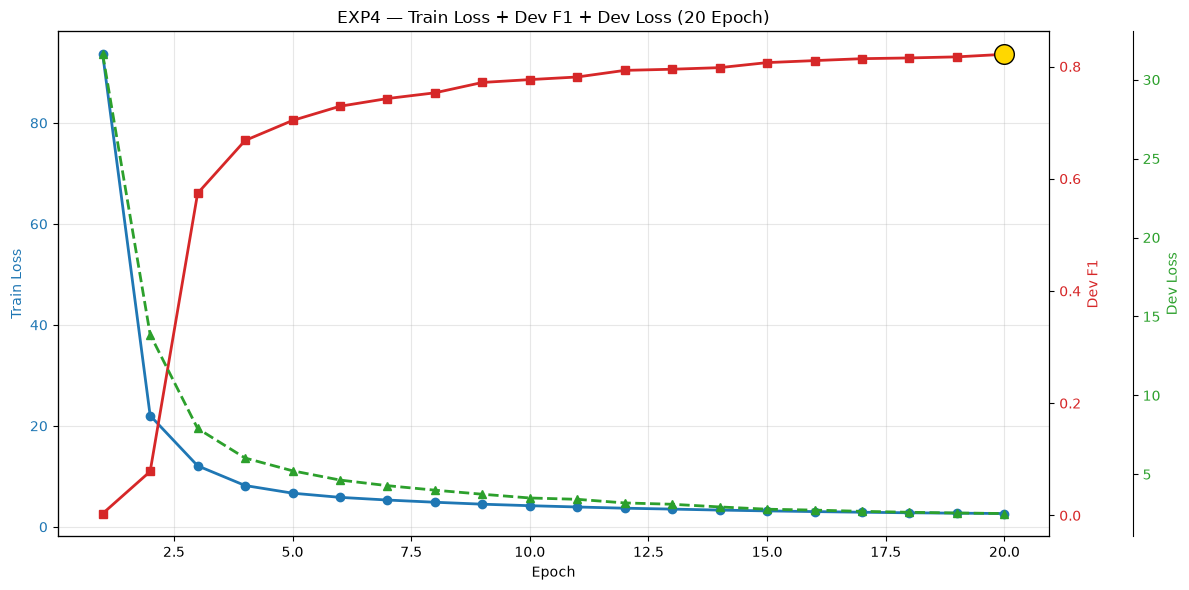

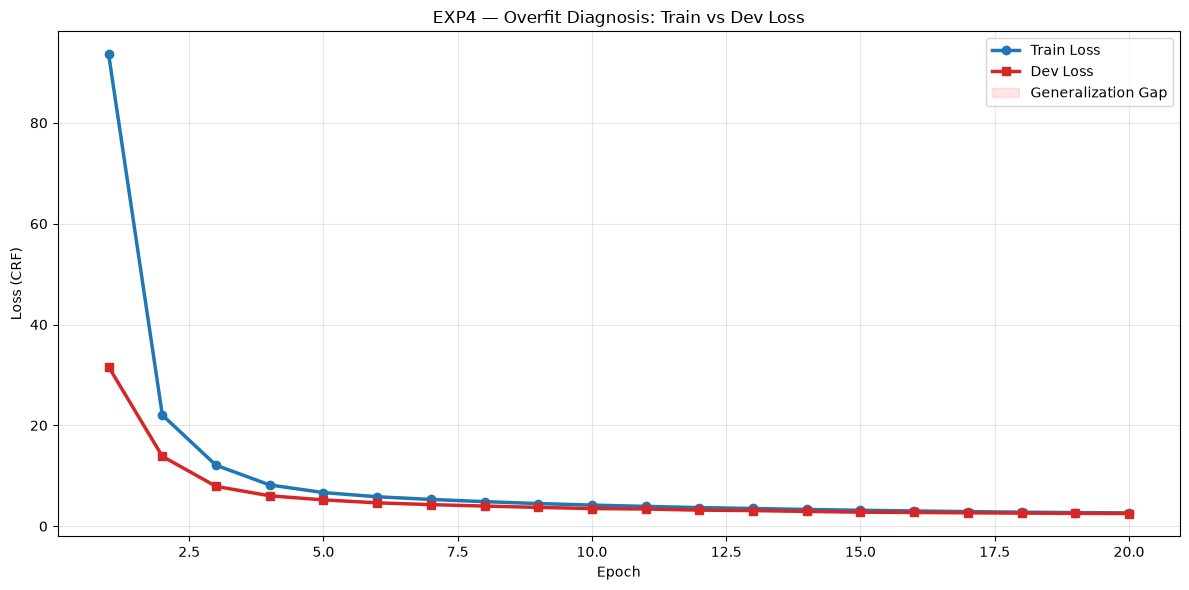

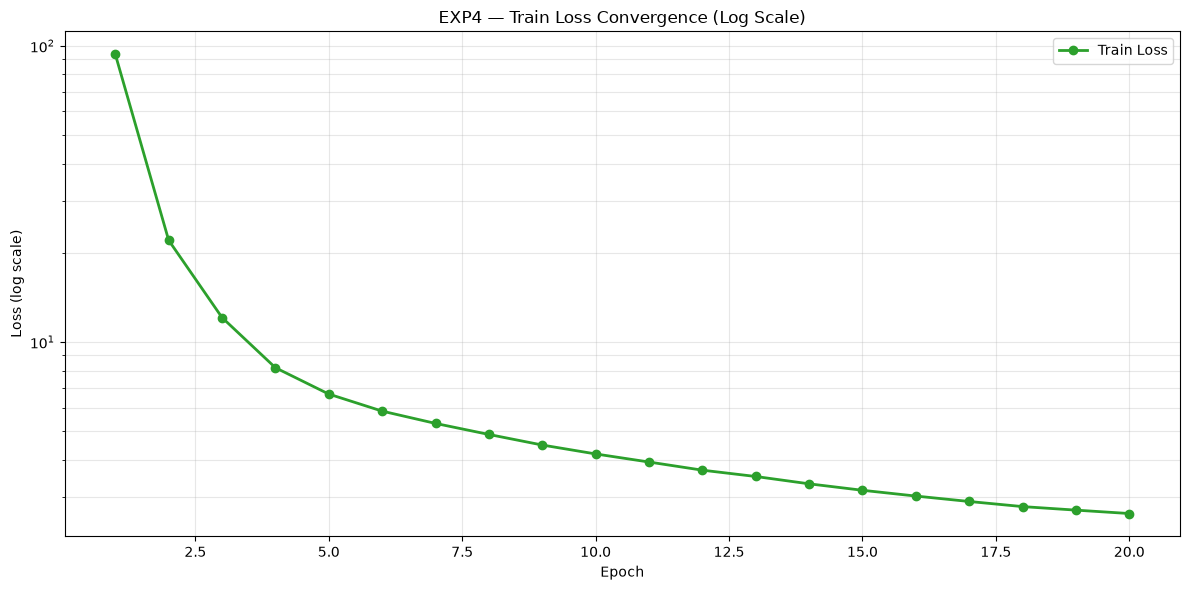

In [33]:
run_output_dir = os.path.dirname(best_path)
log_path = os.path.join(run_output_dir, "training_log.csv")
df_log = pd.read_csv(log_path)

print("=" * 80)
print("TRAINING LOG — 20 EPOCH (EXP4 with Dev Set)")
print("=" * 80)
display(df_log)

best_idx = df_log["dev_f1"].idxmax()
best_row = df_log.loc[best_idx]
print(f"\nBest epoch (dev): {int(best_row['epoch'])} | Best Dev F1: {float(best_row['dev_f1']):.4f}")
if 'dev_loss' in df_log.columns:
    print(f"Best dev loss: {float(best_row['dev_loss']):.4f}")
print(f"Total epoch completed: {len(df_log)}")

# === Plot 1: Train Loss + Dev F1 + Dev Loss ===
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(df_log['epoch'], df_log['train_loss'], marker='o', color='tab:blue', linewidth=2, label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df_log['epoch'], df_log['dev_f1'], marker='s', color='tab:red', linewidth=2, label='Dev F1')
ax2.set_ylabel('Dev F1', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

if 'dev_loss' in df_log.columns:
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(df_log['epoch'], df_log['dev_loss'], marker='^', color='tab:green', linewidth=2, linestyle='--', label='Dev Loss')
    ax3.set_ylabel('Dev Loss', color='tab:green')
    ax3.tick_params(axis='y', labelcolor='tab:green')

ax2.scatter([int(best_row['epoch'])], [float(best_row['dev_f1'])], s=200, color='gold', edgecolor='black', zorder=5,
           label=f"Best Dev F1 = {float(best_row['dev_f1']):.4f}")
plt.title('EXP4 — Train Loss + Dev F1 + Dev Loss (20 Epoch)')
fig.tight_layout()
plt.savefig(os.path.join(run_output_dir, "training_curve_exp4.png"), dpi=180)
plt.show()

# === Plot 2: Overfit Diagnosis ===
if 'dev_loss' in df_log.columns:
    plt.figure(figsize=(12, 6))
    plt.plot(df_log['epoch'], df_log['train_loss'], marker='o', linewidth=2.5, label='Train Loss', color='tab:blue')
    plt.plot(df_log['epoch'], df_log['dev_loss'], marker='s', linewidth=2.5, label='Dev Loss', color='tab:red')
    plt.fill_between(df_log['epoch'], df_log['train_loss'], df_log['dev_loss'],
                     where=(df_log['dev_loss'] > df_log['train_loss']),
                     color='red', alpha=0.1, label='Generalization Gap')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (CRF)')
    plt.title('EXP4 — Overfit Diagnosis: Train vs Dev Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(run_output_dir, "overfit_diagnosis_exp4.png"), dpi=180)
    plt.show()

# === Plot 3: Train Loss (log scale) ===
plt.figure(figsize=(12, 6))
plt.plot(df_log['epoch'], df_log['train_loss'], marker='o', linewidth=2, color='tab:green', label='Train Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('EXP4 — Train Loss Convergence (Log Scale)')
plt.grid(True, alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(run_output_dir, "train_loss_exp4.png"), dpi=180)
plt.show()

In [34]:
print("=" * 80)
print("RINGKASAN AKHIR — EXP4 (64/16/20 Split)")
print("=" * 80)
print(f"Best Dev Epoch       : {int(best_row['epoch'])}")
print(f"Best Dev F1          : {float(best_row['dev_f1']):.4f}")
print(f"Best Dev Precision   : {float(best_row['dev_precision']):.4f}")
print(f"Best Dev Recall      : {float(best_row['dev_recall']):.4f}")
print(f"Final Train Loss     : {df_log['train_loss'].iloc[-1]:.4f}")
if 'dev_loss' in df_log.columns:
    print(f"Final Dev Loss       : {df_log['dev_loss'].iloc[-1]:.4f}")
    gap = df_log['dev_loss'] - df_log['train_loss']
    print(f"Generalization Gap (final): {gap.iloc[-1]:.4f}")
print("\n--- Perbandingan dengan EXP3 ---")
print(f"  EXP3 (leaked test)  : F1=0.913 (data leakage)")
print(f"  EXP4 (dev set)      : F1={float(best_row['dev_f1']):.4f} (development set)")
print(f"  EXP4 (test set)     : F1={float(final_results['overall_f1']):.4f} (unseen test set)")
print("=" * 80)

RINGKASAN AKHIR — EXP4 (64/16/20 Split)
Best Dev Epoch       : 20
Best Dev F1          : 0.8218
Best Dev Precision   : 0.8531
Best Dev Recall      : 0.7927
Final Train Loss     : 2.6341
Final Dev Loss       : 2.5121
Generalization Gap (final): -0.1219

--- Perbandingan dengan EXP3 ---
  EXP3 (leaked test)  : F1=0.913 (data leakage)
  EXP4 (dev set)      : F1=0.8218 (development set)
  EXP4 (test set)     : F1=0.8257 (unseen test set)
